In [3]:
a = [1,2,3]
if isinstance(a, list):
    print("a is a list")

a is a list


In [20]:
e = 1.602e-19  # elementary charge, C
v_e = 2*3.1415*((3393.5+150)*1e3)/(24*3600)  # m/s
n = 1e9 # m^-3, n = n_e = n_i
u = 256 # m/s, neutral wind speed
J_wind = n*e*u # A/m^2
print('J_wind = ', J_wind, 'A/m^2')
J_wind *= 1e9 # convert to nA/m^2
J_crust = -n*e*v_e # A/m^2
print('J_crust = ', J_crust, 'A/m^2')
J_crust *= 1e9 # convert to nA/m^2
print('J_wind = ', J_wind, 'nA/m^2')
print('J_crust = ', J_crust, 'nA/m^2')
J_total = J_wind + J_crust
print('J_total = ', J_total, 'nA/m^2')

J_wind =  4.10112e-08 A/m^2
J_crust =  -4.128081530208333e-08 A/m^2
J_wind =  41.0112 nA/m^2
J_crust =  -41.28081530208333 nA/m^2
J_total =  -0.26961530208333073 nA/m^2


In [1]:
import numpy as np
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings("ignore")

# Set the working directory to the project root directly
# Since this notebook is in scripts/, go to the parent directory
project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

import scripts.utils as ut
import cmcrameri.cm as cmc

# import scripts.data_conversion as dc

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


In [10]:
df = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['alt', 'lat', 'lon'])[:3]
df

,alt,lat,lon
0,1798.97,49.8091,163.276
1,1797.63,49.8380,163.293
2,1796.30,49.8669,163.310


In [8]:
target_ls = 270
angle_half_band = 30
ls = torch.load('data/Ls_series.pt')
n1 = len(ls)
lower_bound = target_ls - angle_half_band
upper_bound = target_ls + angle_half_band
lower_bound = lower_bound % 360
upper_bound = upper_bound % 360
if lower_bound > upper_bound:
    condition2 = (ls >= lower_bound) | (ls <= upper_bound)
else:
    condition2 = (ls <= upper_bound) & (ls >= lower_bound)

ls = ls[condition2]
n2 = len(ls)
print(f'{n2*100/n1:.1f}%')

15.4%


In [ ]:
def sample_unit_sphere(n):
    x = np.random.normal(size=(n,3))
    x /= np.linalg.norm(x, axis=1, keepdims=True)
    return x

u = np.array([1,1,1]) # fixed vector
b = sample_unit_sphere(10000) # random vectors on unit sphere
cross_products = []
u_perpendiculars = []
for line in range(len(b)):
    cross_products.append(np.cross(u, b[line,:]))
    u_perpendicular = np.cross(b[line,:], cross_products[-1])
    # u_perpendicular must have the length of the projection of u onto u_perpendicular
    proj_u_on_b = (np.dot(u, b[line,:]) / np.dot(b[line,:], b[line,:])) * b[line,:]
    u_perp_vector = u - proj_u_on_b
    u_perpendicular = (np.linalg.norm(u_perp_vector) / np.linalg.norm(u_perpendicular)) * u_perpendicular
    u_perpendiculars.append(u_perpendicular)
cross_products = np.array(cross_products)
print(np.mean(cross_products, axis=0))
print('---')
u_perpendiculars = np.array(u_perpendiculars)
print(np.mean(u_perpendiculars, axis=0))
print(f'Norm of u: {np.linalg.norm(u)}')
print(f'Norm of mean u_perpendicular: {np.linalg.norm(np.mean(u_perpendiculars, axis=0))}')

[ 0.0074116  -0.00635113 -0.00106048]
---
[0.67641786 0.66599189 0.66708745]
Norm of u: 1.1547005383792515
Norm of mean u_perpendicular: 1.1602120419103006


### compare B_crust_avg and J

In [2]:
import pandas as pd

def get_B_and_J(season):
    
    crustal_field = pd.read_csv(f'predictions/crustal_field_rotation_avg_{season}_150km_fibonacci.csv')
    print(crustal_field.shape)
    if season == 'winter':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_winter.csv')
    elif season == 'summer':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_summer.csv')
    elif season == 'autumn':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to31_150km_fibonacci_automn.csv')
    elif season == 'spring':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to11_150km_fibonacci_spring.csv')

    deg_max = 85
    condition = (crustal_field['lat'] <= 60) & (crustal_field['lat'] >= -60) & (crustal_field['lon'] >= -deg_max) & (crustal_field['lon'] <= deg_max)
    # condition = (crustal_field['lon'] >= -95) & (crustal_field['lon'] <= 95)

    crustal_field = crustal_field[condition]
    current_field = current_field[condition]
    print(crustal_field.shape)
    Jtotal = 0.0
    for i in ['x','y','z']:
        Jtotal += (current_field['J'+i].values)**2
    Jtotal = np.sqrt(Jtotal)
    current_field['Jtotal'] = Jtotal

    cos_lat = np.cos(np.deg2rad(crustal_field['lat'].values))
    crustal_field['B_chapman'] = (crustal_field['B'].values) * np.exp(1-1/cos_lat)
    # J_h = np.sqrt(current_field['Jp'].values**2 + current_field['Jt'].values**2)

    return crustal_field['B_chapman'].values, current_field['Jtotal'].values
    return crustal_field['B'].values, current_field['Jtotal'].values
    B_h = np.sqrt(crustal_field['Bp'].values**2 + crustal_field['Bt'].values**2)
    B_h_scaled = B_h * np.exp(1-1/cos_lat)
    return B_h_scaled, current_field['Jp'].values

# plt.xscale('log')

In [3]:
# season = 'spring'  # 'spring', 'autumn', None, 'summer', 'winter'
B_scaled_seasons = []
J_seasons = []
for season in ['spring', 'autumn', 'summer', 'winter']:
    B_scaled, J = get_B_and_J(season)
    B_scaled_seasons.append(B_scaled)
    J_seasons.append(J)

B_scaled = np.concatenate(B_scaled_seasons)
J = np.concatenate(J_seasons)
J = abs(J)

(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)


(1472236,) (1472236,)


Text(0, 0.5, 'J total (nA/m2)')

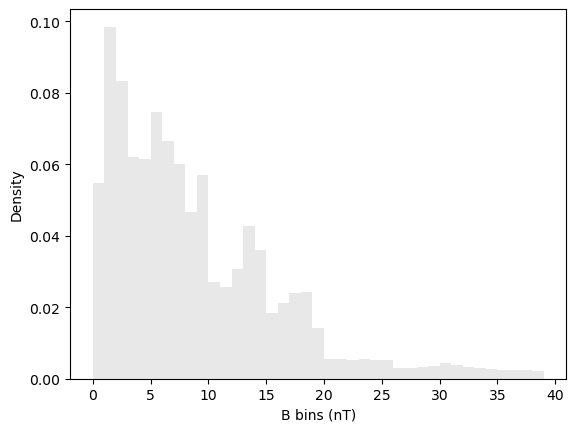

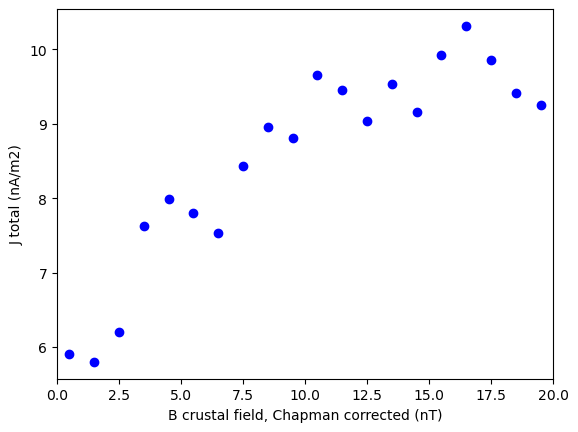

In [4]:
print(B_scaled.shape, J.shape)

plt.figure()
B_bins = np.arange(0,40,1)
J_means = []
J_std = []
for i in range(len(B_bins)-1):
    bin_mask = (B_scaled >= B_bins[i]) & (B_scaled < B_bins[i+1])
    J_mean = np.mean(J[bin_mask])
    J_means.append(J_mean)
    J_std.append(np.std(J[bin_mask]))
plt.hist(B_scaled, bins=B_bins, color='lightgray', alpha=0.5, density=True)
plt.xlabel('B bins (nT)')
plt.ylabel('Density')

plt.figure()
# plt.errorbar(B_bins[:-1]+0.5, J_means, yerr=J_std, fmt='o', color='blue')
plt.scatter(B_bins[:-1]+0.5, J_means, color='blue')
plt.xlim(0,20)
plt.xlabel('B crustal field, Chapman corrected (nT)')
plt.ylabel('J total (nA/m2)')
# plt.savefig('../figures/rotation_avg/Jtotal_vs_B_chapman_rotation_avg_4seasons_max20.png', dpi=300)

### wind speed vs current analysis

In [41]:
print(300/3.6)

83.33333333333333


In [46]:
# rigid_body_speed = (3393.5+150)*1e3*2*3.1415/(24*3600)  # m/s
n = np.array([3*1e4,1e5])*1e6  # m^-3
e = 1.602e-19  # elementary charge, C
J = np.array([-1,-25])*1e-9  # A/m^2
u_max = (J[1]/(n[0]*e))*3/2 # m/s
u_min = (J[0]/(n[1]*e))  # m/s
print('Estimated neutral wind speed u (max) = ', u_max, 'm/s')
print('Estimated neutral wind speed u (min) = ', u_min, 'm/s')

Estimated neutral wind speed u (max) =  -7.8027465667915115 m/s
Estimated neutral wind speed u (min) =  -0.062421972534332085 m/s


In [49]:
# elementary mass
m = 9.11e-31  # kg
B = 10*1e-9  # T
gyro_freq = e*B/m  # rad/s
print('Gyro frequency = ', gyro_freq, 'rad/s')
# in s-1:
print('Gyro frequency = ', gyro_freq/(2*np.pi), 'Hz')

Gyro frequency =  1758.5071350164656 rad/s
Gyro frequency =  279.8751030002375 Hz


### L-curve analysis for smoothness reg tuning

In [ ]:
lambdas = np.logspace(-8,11,num=20)

lambdas_true = []
mses = []
smoothness = []
validations = []

for l in lambdas:
    # folder_formats = [
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0e}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0f}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l}'
    # ]
    # for folder_name in folder_formats:
    #     try:
    #         mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
    #         smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
    #         # validations.append(np.load(f'{folder_name}/val_loss_hist.npy')[-1])
    #         lambdas_true.append(l)
    #         break
    #     except:
    #         continue
    if l == 1e9:
        continue
    folder_name = f'models/PINN_ext_smoothness_reg_{l:.0e}'
    try:
        mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
        smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
        lambdas_true.append(l)
    except:
        continue
    

print(len(mses), 'models')
cmap = cmc.berlin(np.linspace(0, 1, len(lambdas_true)))
plt.figure(figsize=(5,4))
plt.plot(smoothness, mses, color = 'k', linewidth = 0.9, linestyle = '--')
for i in range(len(lambdas_true)):
    plt.scatter(smoothness[i], mses[i], label=f'{lambdas_true[i]:.0e}', c=cmap[i])
plt.xlabel('Roughness')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=1,title='Smoothness lambda')
plt.tight_layout()
plt.show()
plt.close()

### L-curve analysis for L1 penalty tuning

In [ ]:
train_hist = np.load('models/PINN_ext_model_18/training_history.npy')
m, c = ut.slope(train_hist, 10)
print(f'Slope: {m}')

In [ ]:
print(5e2)

In [ ]:
lambdas = [1e-7, 5e-7, 1e-6, 2e-6, 5e-6, 7e-6, 1e-5]
models =  [    27, 29, 19,   26,   23,   280, 21]
mses = []
l1s = []
for model in models:
    try:
        mses.append(np.load(f'models/PINN_ext_model_{model}/training_history.npy')[-1])
        l1s.append(np.load(f'models/PINN_ext_model_{model}/l1_history.npy')[-1])
    except:
        mses.append(None)
        l1s.append(None)

condition = np.array([i is not None for i in mses])
print(sum(condition))
print(condition)
mses = np.array(mses)[condition]
l1s = np.array(l1s)[condition]
lambdas = np.array(lambdas)[condition]

cmap = cmc.berlin(np.linspace(0, 1, len(lambdas)))
# plt.plot(l1s, mses, color = 'k')
for i in range(len(mses)):
    plt.scatter(l1s[i], mses[i], label=lambdas[i], c=cmap[i])
plt.xlabel('L1')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=2,title='L1 lambda')
plt.show()
plt.close()

### ensemble of models

In [ ]:
tensor_a = torch.tensor([[1,2,3],[4,5,6]], dtype=torch.float32)
tensor_b = tensor_a.clone()
tensor_c = tensor_a.clone()
# tensor_b = torch.tensor([4,5,6], dtype=torch.float32)
# tensor_c = torch.tensor([7,8,9], dtype=torch.float32)
tensor_list = torch.vstack((tensor_a,tensor_b))
tensor_list = torch.vstack((tensor_list,tensor_c))
print(tensor_list)
tensor_mean = torch.mean(tensor_list, dim = 0)
print(tensor_mean)


In [ ]:
models = [1,3,6,10,11,14]
epochs = [715,9325,"last","last","last","last"]
for model,epoch in zip(models,epochs):
    df = pd.read_csv(f'predictions/PINN_MSO_model{model}_epoch{epoch}_150km_fibonacci.csv')
    if model == 1:
        df_sum = df.copy()
    else:
        df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] += df[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']]

df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] /= len(models)

df_sum.to_csv('predictions/PINN_MSO_150km_models_1_3_6_10_11_14.csv')

### Hyperparameter tuning / training analysis

In [ ]:
print(np.arange(1,2))

In [ ]:
num_hidden_layers=3,
num_neurons_per_layer=32,
num_neurons = np.ones(num_hidden_layers, dtype=int)*num_neurons_per_layer
print(num_neurons)

In [ ]:
bs = 3
train_hist = np.load(f'models/PINN_ext_bootstrap_{bs}/val_loss_hist.npy')
plt.plot(train_hist)
plt.yscale('log')
plt.grid(axis='both',which='both')
# plt.ylim([train_hist[0],6.02933*1e1])
# plt.ylim([60.2,60.4])

### Calculator

In [ ]:
input = torch.load('data/position_mso.pt')
print(f'input mean = {torch.mean(input)}, std = {torch.std(input)}')
alt = torch.load('data/position_pc.pt')[:,0]
alt = alt.unsqueeze(1)
print(f'Alt mean = {torch.mean(alt)}, std = {torch.std(alt)}')
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(f'Target mean = {torch.mean(target)} std = {torch.std(target)}')

### File conversion testing

In [ ]:
model_params = np.load('models/TEST_PINN_ext_model_8/model_params.npy', allow_pickle=True).item()
print(model_params['alt_std'])

In [ ]:
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(len(target))
# print('Min and max of target: ', torch.min(target), torch.max(target))
# print('Mean and std of target: ', torch.mean(target), torch.std(target))
# randomly downsample target to compute quantiles faster
# target_downsampled = target[torch.randperm(target.size(0))[:10000]]
# print('q1, median, q3 of target: ', torch.quantile(target_downsampled,0.25), torch.median(target_downsampled), torch.quantile(target_downsampled,0.75))
# print('IQR*1.5: ', 1.5*(torch.quantile(target_downsampled,0.75)-torch.quantile(target_downsampled,0.25)))

condition = (target <= 30) & (target >= -30)
condition = torch.any(condition, dim=1)
target = target[condition]
print(len(target))


In [ ]:
print(0.25*3393.5)

In [ ]:
input_1 = torch.load('data/position_mso_spherical.pt')
alt_1 = input_1[:,0].unsqueeze(1)
# input_2 = torch.load('data/position_pc.pt')
# alt_2 = input_2[:,0].unsqueeze(1)
# print(torch.sum(abs(alt_1-alt_2)))
id = np.random.randint(len(alt_1),size = 100000)
alt_1 = alt_1[id]
print(max(alt_1))

In [ ]:
input = torch.load('data/position_mso.pt')
n = len(input)
alt = torch.load('data/position_pc.pt')[:,0]
condition = alt <= 600 #km, only low altitude!
input = input[condition]
alt = alt[condition]

print(f'Data size : {len(input)*100/n:.2f} %')
print(f'Mean value : {torch.mean(input)}')
print(f'Standard deviation : {torch.std(input)}')
print('')
print(f'Mean alt : {torch.mean(alt)}')
print(f'Standard deviation alt : {torch.std(alt)}')


In [ ]:
print(np.log(21730))

In [ ]:
df = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['PC Bx data', 'PC By data', 'PC Bz data'])
# df['SS colat'] = 90 - df['SS lat']
# df['sin_colat'] = np.sin(np.radians(df['SS colat']))
# df['cos_colat'] = np.cos(np.radians(df['SS colat']))
# df['sin_lon'] = np.sin(np.radians(df['SS lon']))
# df['cos_lon'] = np.cos(np.radians(df['SS lon']))
# df = df.drop(columns=['SS lat','SS lon','SS colat'])
# print(df.head())
observation_pc = torch.tensor(df.values, dtype=torch.float32)
# torch.save(observation_pc, 'data/observation_pc.pt')



In [ ]:
print(torch.mean(alt))

In [ ]:
# test position file
position = torch.load('data/position_pc.pt')
position_10000_random_picks = position[torch.randperm(position.size(0))[:10000]]
print(min(position_10000_random_picks[:, 0]), max(position_10000_random_picks[:, 0]))
print(min(position_10000_random_picks[:, 1]), max(position_10000_random_picks[:, 1]))
print(min(position_10000_random_picks[:, 2]), max(position_10000_random_picks[:, 2]))

In [ ]:
# compare crustal field from L19 and D25 (only scalar)
df = dc.format_sample()
df = df[['BL PC Bx','BL PC By','BL PC Bz']].values
crustal_field_pc = torch.load('data/crustal_field_pc.pt')
crustal_field_pc = crustal_field_pc[:len(df)]
df = torch.tensor(df, dtype=torch.float32)
B_l19 = np.sqrt(df[:,0]**2 + df[:,1]**2 + df[:,2]**2)
B_D25 = np.sqrt(crustal_field_pc[:,0]**2 + crustal_field_pc[:,1]**2 + crustal_field_pc[:,2]**2)
mse = torch.mean((B_l19 - B_D25)**2)
print("MSE crustal field (nT^2): ", mse.item())

In [ ]:
df = dc.format_sample()
df = df[['BL SS Bx','BL SS By','BL SS Bz']].values
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
crustal_field_mso = crustal_field_mso[:len(df)]
df = torch.tensor(df, dtype=torch.float32)

mse = torch.mean((crustal_field_mso-df)**2)
print("MSE crustal field (nT^2): ", mse.item())

### Curl tests

#### 2D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
X,Y = np.meshgrid(x0, y0)
x,y = X.ravel(), Y.ravel()
plt.figure()
plt.quiver(X,Y,Y,-X)
plt.show()


In [ ]:
def tensor(t):
    return torch.tensor(t,dtype = torch.float32)


Input = torch.stack((tensor(x), tensor(y) ), dim=1)
Input = torch.tensor(Input,requires_grad=True)
Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1]
Output1[:,1] = -Input[:,0]
# gradient = torch.ones_like(Input)
Output1.sum().backward()
print(Input.grad.shape)

curl1 = Input.grad[:,0] - Input.grad[:,1]
print(torch.unique(curl1).item())

#### 3D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad=True

Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output1[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output1[:,2] = 0


Output1[:,0].sum().backward(retain_graph=True)
dBx_dx = Input.grad[:,0].clone()
dBx_dy = Input.grad[:,1].clone()
dBx_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,1].sum().backward(retain_graph=True)
dBy_dx = Input.grad[:,0].clone()
dBy_dy = Input.grad[:,1].clone()
dBy_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,2].sum().backward(retain_graph=True)
dBz_dx = Input.grad[:,0].clone()
dBz_dy = Input.grad[:,1].clone()
dBz_dz = Input.grad[:,2].clone()

curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
cond = curl[:,2] > 0
print(curl[:,2][cond])

analytical_curl = torch.zeros_like(Input)
analytical_curl[:,0] = 0
analytical_curl[:,1] = 0
analytical_curl[:,2] = 3*Input[:,0]**2 - 3*Input[:,1]**2

print(analytical_curl[:,2][cond])



#### 3D curl(curl()) in cartesian coordinates

In [ ]:
def curl(Input, Output):
    
    Output[:,0].sum().backward(retain_graph=True)
    dBx_dx = Input.grad[:,0].clone()
    dBx_dy = Input.grad[:,1].clone()
    dBx_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,1].sum().backward(retain_graph=True)
    dBy_dx = Input.grad[:,0].clone()
    dBy_dy = Input.grad[:,1].clone()
    dBy_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,2].sum().backward(retain_graph=True)
    dBz_dx = Input.grad[:,0].clone()
    dBz_dy = Input.grad[:,1].clone()
    dBz_dz = Input.grad[:,2].clone()

    curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
    return curl



x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad = True
Output = torch.zeros_like(Input)
Output[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output[:,2] = 0

curl1 = curl(Input, Output)

# checking results
tensors_combined = torch.concatenate((curl1,Input),dim=1)
tensors_combined = tensors_combined[cond].detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        
    elif (tensors_combined[i,2] == tensors_combined[i-1,2]):
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        




In [ ]:
def curl_differentiable(Input, Output):
    """
    Compute curl while maintaining computational graph for higher-order derivatives
    """
    # Use torch.autograd.grad instead of .backward() to maintain graph
    
    # Compute all partial derivatives using the same logic as the working version
    # ∂Bx/∂(x,y,z)

    grad_Bx = torch.autograd.grad(Output[:,0].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBx_dx, dBx_dy, dBx_dz = grad_Bx[:,0], grad_Bx[:,1], grad_Bx[:,2]
    
    # ∂By/∂(x,y,z)  
    grad_By = torch.autograd.grad(Output[:,1].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBy_dx, dBy_dy, dBy_dz = grad_By[:,0], grad_By[:,1], grad_By[:,2]
    
    # ∂Bz/∂(x,y,z)
    grad_Bz = torch.autograd.grad(Output[:,2].sum(), Input, create_graph=True, retain_graph=True)[0] 
    dBz_dx, dBz_dy, dBz_dz = grad_Bz[:,0], grad_Bz[:,1], grad_Bz[:,2]
    
    # Curl formula: (∂Bz/∂y - ∂By/∂z, ∂Bx/∂z - ∂Bz/∂x, ∂By/∂x - ∂Bx/∂y)
    curl_x = dBz_dy - dBy_dz
    curl_y = dBx_dz - dBz_dx  
    curl_z = dBy_dx - dBx_dy
    
    return torch.stack((curl_x, curl_y, curl_z), dim=1)

# Test and compare both versions
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input_new = torch.stack((tensor(x), tensor(y), tensor(z)), dim=1)
Input_new.requires_grad_(True)

Output_new = torch.zeros_like(Input_new)
Output_new[:,0] = Input_new[:,1] ** 3 - 9* Input_new[:,1]
Output_new[:,1] = Input_new[:,0] ** 3 - 9* Input_new[:,0]  
Output_new[:,2] = 0

print("Computing curl with differentiable version...")
curl1_diff = curl_differentiable(Input_new, Output_new)
# check_result(curl1_diff, Input_new)

curl2_diff = curl_differentiable(Input_new, curl1_diff)







tensors_combined = torch.concatenate((curl2_diff,Input),dim=1)
tensors_combined = tensors_combined.detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
    elif (tensors_combined[i,0:2] == tensors_combined[i-1,0:2]).all():
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
